In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_percentMito', 
            'RNA_tSNE2', 'RNA_nFeatures', 'RNA_leiden_cluster', 'RNA_cluster', 'RNA_tSNE1', 
            'RNA_percentRibo', 'RNA_UMAP1', 'RNA_UMAP2'
   RNA assay has 13632 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs'

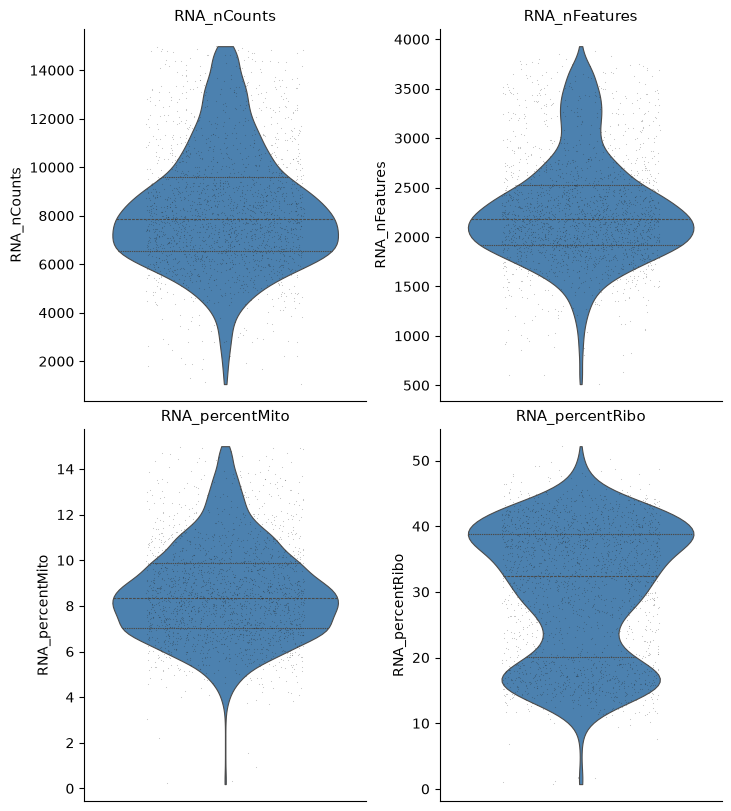

In [2]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

Active cells before filter: 5025
Active cells after filter: 3940


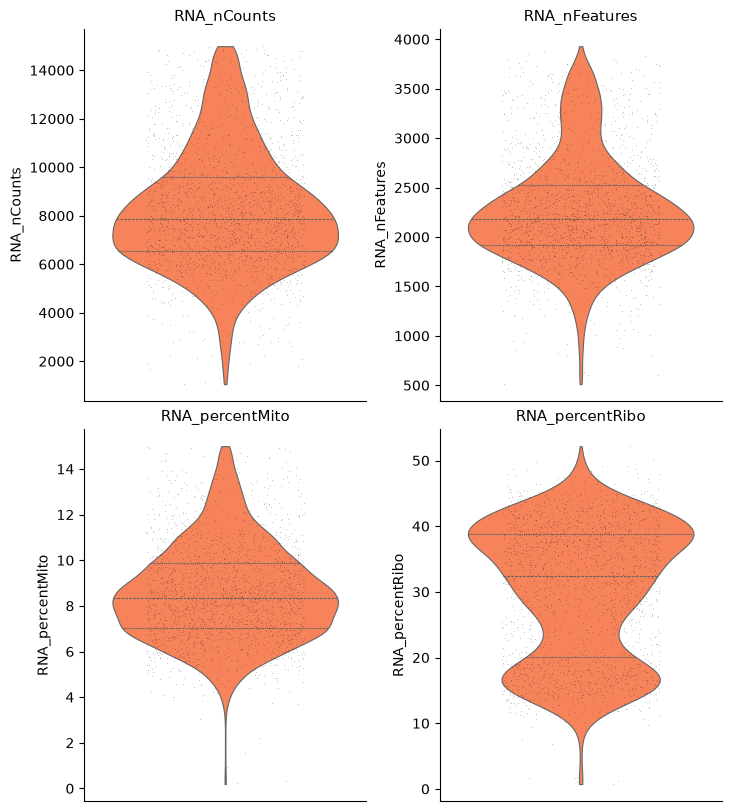

In [3]:
# Prepared stores may already have an `I` filter. Reset so before/after counts are meaningful.
ds.cells.reset_key(key='I')
n_before = int(ds.cells.fetch_all('I').sum())
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
n_after = int(ds.cells.fetch_all('I').sum())
print(f'Active cells before filter: {n_before}')
print(f'Active cells after filter: {n_after}')
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

In [4]:
ds.RNA.add_percent_feature(feat_pattern='^HB[AB]', name='RNA_percentHB')
if 'RNA_percentHB' in ds.cells.columns:
    print(
        ds.cells.to_pandas_dataframe(['RNA_percentHB'], key='I')['RNA_percentHB']
        .describe()
    )
else:
    print('No features matched ^HB[AB] in this store')

count    3940.000000
mean        0.000758
std         0.015413
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.584795
Name: RNA_percentHB, dtype: float64


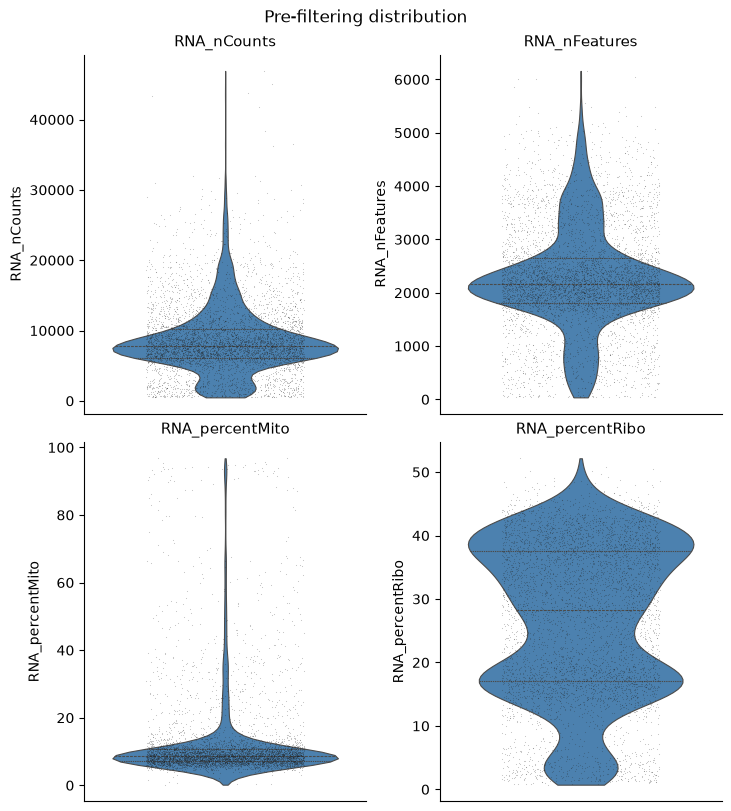

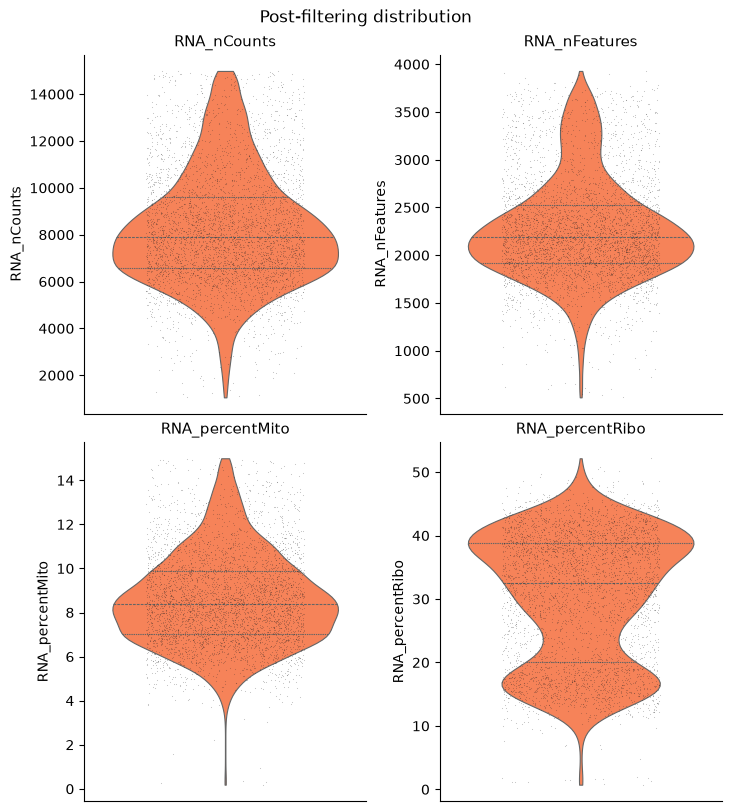

In [5]:
ds.auto_filter_cells(show_qc_plots=True)

In [6]:
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_leiden_clustering(resolution=0.5)
score_col = ds.run_doublet_detection(cluster_key='RNA_leiden_cluster')
ds.run_umap(n_epochs=100, spread=5, min_dist=1, parallel=True)

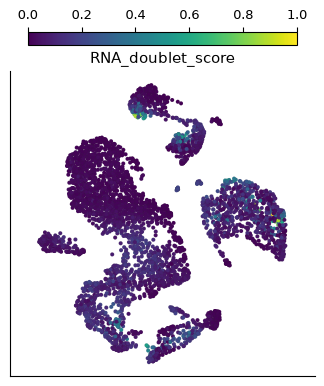

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=score_col,
)

In [8]:
ds.cells.to_pandas_dataframe(columns=[score_col], key='I').describe()

,RNA_doublet_score
count,3940.000000
mean,0.075196
std,0.093339
min,0.000000
25%,0.016056
50%,0.045406
75%,0.102439
max,1.000000
